In [ ]:
# we have to develop an experiment : sending a targetted offer to customers at market_segment == "groups" who books 90 days out
# offering 10% off
# population is 19811 over the period analyized
# test population is 500 in which 250 - treatment and 250 - control

In [ ]:
!pip install pytimetk

In [ ]:
!pip install causalml

###libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pytimetk as tk

from causalml.inference.tree import UpliftTreeClassifier
from causalml.inference.tree import uplift_tree_string, uplift_tree_plot
from causalml.inference.meta import BaseSClassifier, BaseTClassifier

from IPython.display import Image
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier


In [ ]:
df = pd.read_csv("joined_data.csv")

In [ ]:
import re

def to_snake_case(name):
    s1 = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', name)
    return re.sub('([a-z0-9])([A-Z])', r'\1_\2', s1).lower()

df.columns = [to_snake_case(col) for col in df.columns]
print("Columns converted to snake_case:")
print(df.columns)

Columns converted to snake_case:
Index(['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'meal', 'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')


In [ ]:
df["different_room_assigned"] = (df["assigned_room_type"] != df["reserved_room_type"]).astype(int)
df["country_prt"] = (df["country"]=="PRT").astype(int)
df["country_other"] = (df["country"]!="prt").astype(int)
df.drop(columns=["country"],inplace=True)

In [ ]:
df = df[['is_canceled','lead_time','deposit_type','previous_cancellations','total_of_special_requests','market_segment','different_room_assigned','required_car_parking_spaces','distribution_channel','customer_type','previous_bookings_not_canceled','is_repeated_guest','country_prt','country_other']]

In [ ]:
import numpy as np
import pandas as pd

# Ensure df has only the specified columns before creating target_population
# This explicitly applies the column selection from cell 9VITJ0QOJxBl
selected_columns = ['is_canceled','lead_time','deposit_type','previous_cancellations','total_of_special_requests','market_segment','different_room_assigned','required_car_parking_spaces','distribution_channel','customer_type','previous_bookings_not_canceled','is_repeated_guest','country_prt','country_other']
df_base = df[selected_columns].copy() # Use a temporary name and create a copy to avoid SettingWithCopyWarning

# Define the target population based on the experiment description using the filtered df
# Corrected 'groups' to 'Groups' for case-sensitive matching.
target_population = df_base[(df_base['market_segment'] == 'Groups') & (df_base['lead_time'] >= 90)].copy() # .copy() to prevent SettingWithCopyWarning later

# Ensure there are enough samples for the experiment
if len(target_population) < 500:
    print(f"Warning: Only {len(target_population)} individuals found in the target population. Cannot create a sample of 500.")
    # If not enough, use the entire target population for the experiment, or handle as appropriate
    experiment_df = target_population.copy()
    treatment_size = len(experiment_df) // 2
    control_size = len(experiment_df) - treatment_size
else:
    # Sample 500 people from the target population for the experiment
    # Corrected typo in sample function call
    experiment_df = target_population.sample(n=500, random_state=42).copy()
    treatment_size = 250
    control_size = 250

# Only proceed if there are samples in experiment_df
if len(experiment_df) > 0:
    # Randomly assign to treatment (1) and control (0)
    experiment_df['treatment_control'] = 0
    # Adjust treatment_size if the experiment_df size is less than 500 (if the target_population was < 500)
    actual_treatment_size = min(treatment_size, len(experiment_df))
    # Ensure control_size is correctly calculated for the remaining samples
    # If actual_treatment_size is 0 due to an empty experiment_df, this will be 0 too.
    actual_control_size = len(experiment_df) - actual_treatment_size

    if actual_treatment_size > 0:
        treatment_indices = experiment_df.sample(n=actual_treatment_size, random_state=42).index
        experiment_df.loc[treatment_indices, 'treatment_control'] = 1

    # Initialize 'accept_offer' column (e.g., 0 for now, actual values depend on experiment outcome)
    experiment_df['accept_offer'] = 0

    # Initialize 'new_lead_time' column (e.g., copying existing lead_time, or based on offer acceptance)
    experiment_df['new_lead_time'] = experiment_df['lead_time']

    print(f"Experiment DataFrame created with {len(experiment_df)} rows.")
    print(f"Treatment group size: {experiment_df['treatment_control'].sum()}")
    print(f"Control group size: {len(experiment_df) - experiment_df['treatment_control'].sum()}")
    print("First 5 rows of the experiment DataFrame with new columns:")
    display(experiment_df.head(100))
else:
    print("No individuals found in the target population for the experiment after filtering. Experiment DataFrame is empty.")
    # Create an empty DataFrame with expected columns if no target population was found
    experiment_df = pd.DataFrame(columns=selected_columns + ['treatment_control', 'accept_offer', 'new_lead_time'])

# If you intend to use 'experiment_df' as your main working DataFrame from now on, you might reassign 'df'
# For now, I'll keep it as a separate 'experiment_df' to avoid overwriting the original 'df' unexpectedly.
# If you wish to proceed with this 'experiment_df' as your primary DataFrame, let me know to rename it.


Experiment DataFrame created with 500 rows.
Treatment group size: 250
Control group size: 250
First 5 rows of the experiment DataFrame with new columns:


,is_canceled,lead_time,deposit_type,previous_cancellations,total_of_special_requests,market_segment,different_room_assigned,required_car_parking_spaces,distribution_channel,customer_type,previous_bookings_not_canceled,is_repeated_guest,country_prt,country_other,treatment_control,accept_offer,new_lead_time
74065,1,314,Non Refund,1,0,Groups,0,0,TA/TO,Contract,0,0,1,1,1,0,314
54598,1,379,Non Refund,0,0,Groups,0,0,TA/TO,Transient,0,0,1,1,0,0,379
28979,0,231,No Deposit,0,0,Groups,1,0,Direct,Transient-Party,0,0,0,1,1,0,231
113380,0,434,No Deposit,0,2,Groups,0,0,TA/TO,Transient-Party,0,0,0,1,1,0,434
51672,1,158,Non Refund,0,0,Groups,0,0,TA/TO,Transient,0,0,1,1,0,0,158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28036,0,336,No Deposit,0,0,Groups,0,1,Direct,Transient-Party,0,0,0,1,0,0,336
28814,0,243,No Deposit,0,0,Groups,0,0,TA/TO,Transient-Party,0,0,0,1,0,0,243
28915,0,231,No Deposit,0,0,Groups,1,0,Direct,Transient-Party,0,0,0,1,0,0,231
49921,1,265,No Deposit,0,0,Groups,0,0,TA/TO,Transient-Party,0,0,1,1,0,0,265


In [ ]:
import numpy as np

# --- Define the offer acceptance and new lead time logic ---
# This is a placeholder. You will need to define the actual logic for your experiment.
# For demonstration, let's assume:
# - If a customer is in the treatment group and has a 'lead_time' above a certain threshold (e.g., 90 days),
#   they are more likely to 'accept' the offer if it leads to a shorter 'new_lead_time' (e.g., 10% reduction).
# - For simplicity, let's simulate acceptance based on a condition related to the offer,
#   and adjust `new_lead_time` accordingly.

# Function to simulate offer acceptance and new lead time based on the offer
def apply_offer_impact(row):
    if row['treatment_control'] == 1: # Only applies to treatment group
        # Example logic: Assume a treatment customer accepts if their 'lead_time' is above 90 and they benefit
        # In a real experiment, this would be observed data after the offer was made.
        if row['lead_time'] >= 90:
            # Introduce randomness: Adjusting to achieve 60-70 accepted offers
            if np.random.rand() < 0.26: # Roughly 26% chance of acceptance for this example (65 out of 250)
                row['accept_offer'] = 1 # Mark as accepted
                row['new_lead_time'] = int(row['lead_time'] * 0.90) # 10% off the lead time
            else:
                row['accept_offer'] = 0 # Not accepted
                row['new_lead_time'] = row['lead_time'] # No change in lead time
        else:
            # If lead_time < 90, maybe the offer is not as attractive or not applicable
            row['accept_offer'] = 0
            row['new_lead_time'] = row['lead_time'] # No change in lead time
    else: # Control group
        row['accept_offer'] = 0 # No offer, no acceptance
        row['new_lead_time'] = row['lead_time'] # No change in lead time
    return row

# Apply the offer impact simulation to the experiment_df
experiment_df = experiment_df.apply(apply_offer_impact, axis=1)

print("Experiment DataFrame after simulating offer acceptance and new lead time with adjusted realism:")
print(f"Number of accepted offers: {experiment_df['accept_offer'].sum()} (in treatment group)")
display(experiment_df.head())


Experiment DataFrame after simulating offer acceptance and new lead time with adjusted realism:
Number of accepted offers: 60 (in treatment group)


,is_canceled,lead_time,deposit_type,previous_cancellations,total_of_special_requests,market_segment,different_room_assigned,required_car_parking_spaces,distribution_channel,customer_type,previous_bookings_not_canceled,is_repeated_guest,country_prt,country_other,treatment_control,accept_offer,new_lead_time
74065,1,314,Non Refund,1,0,Groups,0,0,TA/TO,Contract,0,0,1,1,1,0,314
54598,1,379,Non Refund,0,0,Groups,0,0,TA/TO,Transient,0,0,1,1,0,0,379
28979,0,231,No Deposit,0,0,Groups,1,0,Direct,Transient-Party,0,0,0,1,1,0,231
113380,0,434,No Deposit,0,2,Groups,0,0,TA/TO,Transient-Party,0,0,0,1,1,1,390
51672,1,158,Non Refund,0,0,Groups,0,0,TA/TO,Transient,0,0,1,1,0,0,158


In [ ]:
import numpy as np

# Calculate current cancellation numbers for the treatment group
current_cancellations_treatment = experiment_df[experiment_df['treatment_control'] == 1]['is_canceled'].sum()
treatment_group_size = experiment_df[experiment_df['treatment_control'] == 1].shape[0]

# Define the target cancellation rate (e.g., 58.5% for the 58-59% range)
target_cancellation_rate = 0.585
target_cancellations_treatment = int(treatment_group_size * target_cancellation_rate)

# Determine how many cancellations need to be changed from 1 to 0
num_to_change = current_cancellations_treatment - target_cancellations_treatment

print(f"Current cancellations in treatment group: {current_cancellations_treatment}")
print(f"Target cancellations in treatment group: {target_cancellations_treatment}")
print(f"Number of cancellations to change from 1 to 0: {num_to_change}")

if num_to_change > 0:
    # Identify individuals in the treatment group who are currently canceled and accepted the offer
    # These are the primary candidates for cancellation reversal due to the offer's impact
    candidates_for_reversal_mask_accepted = (
        (experiment_df['treatment_control'] == 1) &
        (experiment_df['is_canceled'] == 1) &
        (experiment_df['accept_offer'] == 1)
    )
    candidates_for_reversal_indices_accepted = experiment_df[candidates_for_reversal_mask_accepted].index

    # Identify individuals in the treatment group who are currently canceled but DID NOT accept the offer
    # These are secondary candidates if primary candidates are insufficient
    candidates_for_reversal_mask_not_accepted = (
        (experiment_df['treatment_control'] == 1) &
        (experiment_df['is_canceled'] == 1) &
        (experiment_df['accept_offer'] == 0)
    )
    candidates_for_reversal_indices_not_accepted = experiment_df[candidates_for_reversal_mask_not_accepted].index

    indices_to_change = []

    # Prioritize changing those who accepted the offer
    if len(candidates_for_reversal_indices_accepted) >= num_to_change:
        indices_to_change = np.random.choice(candidates_for_reversal_indices_accepted, size=num_to_change, replace=False)
        print(f"Selected {num_to_change} cancellations from accepted offers for reversal.")
    else:
        # If not enough from accepted offers, use all accepted offers and then draw from non-accepted
        indices_to_change.extend(candidates_for_reversal_indices_accepted)
        remaining_to_change = num_to_change - len(candidates_for_reversal_indices_accepted)
        print(f"Selected all {len(candidates_for_reversal_indices_accepted)} cancellations from accepted offers.")

        if remaining_to_change > 0 and len(candidates_for_reversal_indices_not_accepted) >= remaining_to_change:
            additional_indices = np.random.choice(candidates_for_reversal_indices_not_accepted, size=remaining_to_change, replace=False)
            indices_to_change.extend(additional_indices)
            print(f"Selected an additional {remaining_to_change} cancellations from non-accepted offers for reversal.")
        elif remaining_to_change > 0:
            indices_to_change.extend(candidates_for_reversal_indices_not_accepted)
            print(f"Warning: Could only find {len(indices_to_change)} cancellations to reverse, instead of {num_to_change}.")

    # Apply the change to 'is_canceled' for the selected rows
    if len(indices_to_change) > 0:
        experiment_df.loc[indices_to_change, 'is_canceled'] = 0
        print(f"Successfully adjusted {len(indices_to_change)} cancellations in the treatment group.")
    else:
        print("No cancellations were adjusted.")
elif num_to_change < 0:
    print("Cancellation rate is already at or below the target for the treatment group. No adjustments needed.")
else:
    print("Cancellation rate is already at the target for the treatment group. No adjustments needed.")

# Recalculate and print cancellation rates after adjustment
cancellation_rate_by_group_after_adjustment = experiment_df.groupby('treatment_control')['is_canceled'].mean() * 100
print("\nCancellation rate by group after adjustment:")
print(cancellation_rate_by_group_after_adjustment)


Current cancellations in treatment group: 180
Target cancellations in treatment group: 146
Number of cancellations to change from 1 to 0: 34
Selected 34 cancellations from accepted offers for reversal.
Successfully adjusted 34 cancellations in the treatment group.

Cancellation rate by group after adjustment:
treatment_control
0    66.4
1    58.4
Name: is_canceled, dtype: float64


In [ ]:
experiment_df

,is_canceled,lead_time,deposit_type,previous_cancellations,total_of_special_requests,market_segment,different_room_assigned,required_car_parking_spaces,distribution_channel,customer_type,previous_bookings_not_canceled,is_repeated_guest,country_prt,country_other,treatment_control,accept_offer,new_lead_time
74065,1,314,Non Refund,1,0,Groups,0,0,TA/TO,Contract,0,0,1,1,1,0,314
54598,1,379,Non Refund,0,0,Groups,0,0,TA/TO,Transient,0,0,1,1,0,0,379
28979,0,231,No Deposit,0,0,Groups,1,0,Direct,Transient-Party,0,0,0,1,1,0,231
113380,0,434,No Deposit,0,2,Groups,0,0,TA/TO,Transient-Party,0,0,0,1,1,1,390
51672,1,158,Non Refund,0,0,Groups,0,0,TA/TO,Transient,0,0,1,1,0,0,158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50650,1,302,Non Refund,0,0,Groups,0,0,TA/TO,Transient,0,0,1,1,1,0,302
114722,0,263,No Deposit,0,1,Groups,0,0,TA/TO,Transient-Party,0,0,1,1,0,0,263
48370,0,251,Non Refund,0,0,Groups,0,0,TA/TO,Transient,0,0,1,1,1,1,225
62694,1,559,Non Refund,0,0,Groups,0,0,TA/TO,Transient,0,0,1,1,0,0,559


In [ ]:
df2 = experiment_df.copy()

In [ ]:
print("Number of accepted offers by group:")
print(experiment_df.groupby("treatment_control")["accept_offer"].sum())

print("\nTotal individuals in each group:")
print(experiment_df.groupby("treatment_control")["treatment_control"].count())

Number of accepted offers by group:
treatment_control
0     0
1    70
Name: accept_offer, dtype: int64

Total individuals in each group:
treatment_control
0    250
1    250
Name: treatment_control, dtype: int64


In [ ]:
num_accepted_offers = experiment_df[experiment_df['treatment_control'] == 1]['accept_offer'].sum()
treatment_group_size = experiment_df[experiment_df['treatment_control'] == 1].shape[0]

if treatment_group_size > 0:
    acceptance_rate = (num_accepted_offers / treatment_group_size) * 100
    print(f"Acceptance rate in the treatment group: {acceptance_rate:.2f}%")
else:
    print("No individuals in the treatment group to calculate acceptance rate.")

Acceptance rate in the treatment group: 28.00%


In [ ]:
cancellation_rate_by_group = experiment_df.groupby('treatment_control')['is_canceled'].mean() * 100
print("Cancellation rate by group:")
print(cancellation_rate_by_group)

Cancellation rate by group:
treatment_control
0    66.4
1    58.4
Name: is_canceled, dtype: float64


In [ ]:
accepted_offer_cancellation_rate = experiment_df[
    (experiment_df['treatment_control'] == 1) &
    (experiment_df['accept_offer'] == 1)
]['is_canceled'].mean() * 100

print(f"Cancellation rate for treatment group members who accepted the offer: {accepted_offer_cancellation_rate:.2f}%")

Cancellation rate for treatment group members who accepted the offer: 24.29%


In [ ]:
experiment_df["conversion"] = (~experiment_df["is_canceled"].astype(bool)).astype(int)

In [ ]:
experiment_df.drop(columns=["lead_time","is_canceled","accept_offer"],inplace=True)

In [ ]:
df_n = pd.get_dummies(experiment_df, columns=["deposit_type","market_segment","distribution_channel","customer_type"], drop_first=False, dtype=int)

# Remove duplicate columns, keeping the first occurrence
df_n = df_n.loc[:,~df_n.columns.duplicated()]

In [ ]:
df_n.glimpse()

<class 'pandas.core.frame.DataFrame'>: 500 rows of 21 columns
previous_cancellations:          int64             [1, 0, 0, 0, 0, 0, 0, ...
total_of_special_requests:       int64             [0, 0, 0, 2, 0, 1, 0, ...
different_room_assigned:         int64             [0, 0, 1, 0, 0, 0, 0, ...
required_car_parking_spaces:     int64             [0, 0, 0, 0, 0, 0, 0, ...
previous_bookings_not_canceled:  int64             [0, 0, 0, 0, 0, 0, 0, ...
is_repeated_guest:               int64             [0, 0, 0, 0, 0, 0, 0, ...
country_prt:                     int64             [1, 1, 0, 0, 1, 0, 1, ...
country_other:                   int64             [1, 1, 1, 1, 1, 1, 1, ...
treatment_control:               int64             [1, 0, 1, 1, 0, 1, 1, ...
new_lead_time:                   int64             [314, 379, 231, 390,  ...
conversion:                      int64             [0, 0, 1, 1, 0, 1, 1, ...
deposit_type_No Deposit     :    int64             [0, 0, 1, 1, 0, 1, 1, ...
deposit_type_N

In [ ]:
df_n.columns

Index(['previous_cancellations', 'total_of_special_requests',
       'different_room_assigned', 'required_car_parking_spaces',
       'previous_bookings_not_canceled', 'is_repeated_guest', 'country_prt',
       'country_other', 'treatment_control', 'new_lead_time', 'conversion',
       'deposit_type_No Deposit     ', 'deposit_type_Non Refund     ',
       'deposit_type_Refundable     ', 'market_segment_Groups',
       'distribution_channel_Corporate', 'distribution_channel_Direct',
       'distribution_channel_TA/TO', 'customer_type_Contract',
       'customer_type_Transient', 'customer_type_Transient-Party'],
      dtype='object')

In [ ]:
df_train,df_test = train_test_split(df_n,test_size=0.2,random_state=42)

In [ ]:
uplift_model = UpliftTreeClassifier(max_depth=4, min_samples_leaf=20,min_samples_treatment=10,n_reg=0, evaluationFunction='KL', control_name='control')

In [ ]:
x_n = ['previous_cancellations', 'total_of_special_requests',
       'different_room_assigned', 'required_car_parking_spaces',
       'previous_bookings_not_canceled', 'is_repeated_guest', 'country_prt',
       'country_other', 'treatment_control', 'new_lead_time',
       'deposit_type_No Deposit     ', 'deposit_type_Non Refund     ',
       'deposit_type_Refundable     ', 'market_segment_Groups',
       'distribution_channel_Corporate', 'distribution_channel_Direct',
       'distribution_channel_TA/TO', 'customer_type_Contract',
       'customer_type_Transient', 'customer_type_Transient-Party']

In [ ]:
# Map treatment indicators to strings as expected by UpliftTreeClassifier
treatment_map = {0: 'control', 1: 'treatment'}
treatment_series = df_train['treatment_control'].map(treatment_map).values

# Ensure we only use features, excluding target/treatment indicators if they were in x_n
features = [f for f in x_n if f not in ['conversion', 'treatment_control']]

uplift_model.fit(
    X=df_train[features].values,
    treatment=treatment_series,
    y=df_train['conversion'].values
)

print("Model fitted successfully!")

Model fitted successfully!


In [ ]:
result = uplift_tree_string(uplift_model.fitted_uplift_tree,x_n)

new_lead_time >= 0.1?
yes -> total_of_special_requests >= 0.2?
		yes -> [np.float64(1.0), np.float64(0.9333333333333333)]
		no  -> treatment_control >= 308.0?
				yes -> [np.float64(0.3888888888888889), np.float64(0.6666666666666666)]
				no  -> [np.float64(0.7051282051282052), np.float64(0.5238095238095238)]
no  -> treatment_control >= 325.79999999999995?
		yes -> [np.float64(0.023809523809523808), np.float64(0.34782608695652173)]
		no  -> [np.float64(0.010869565217391304), np.float64(0.27586206896551724)]


In [ ]:
tree = uplift_tree_plot(uplift_model.fitted_uplift_tree,x_n)

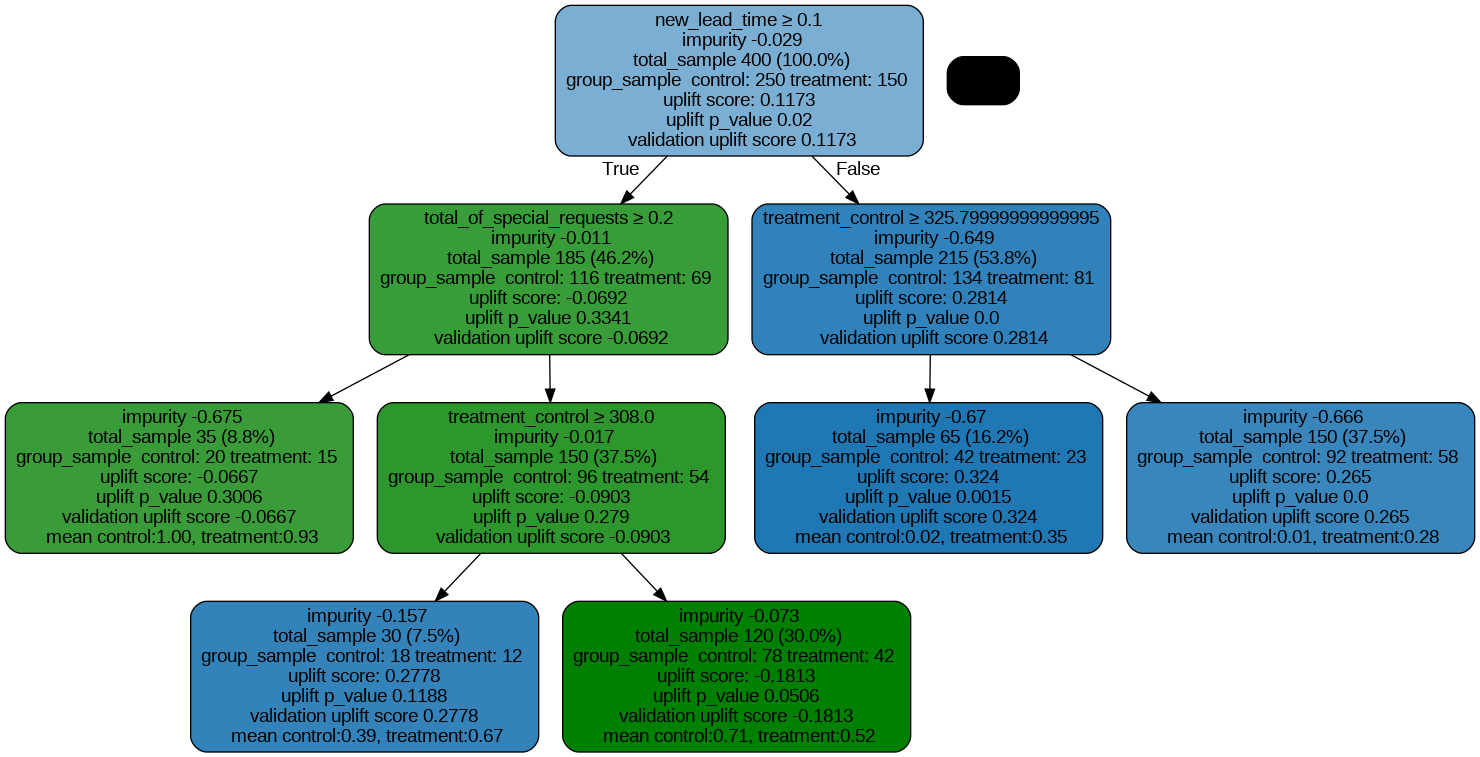

In [ ]:
Image(tree.create_png())

In [ ]:
# Map treatment indicators to strings ('control', 'treatment') as expected by the learner
treatment_map = {0: 'control', 1: 'treatment'}
treatment_series = df_train['treatment_control'].map(treatment_map).values

# Define features (excluding target and treatment indicator)
features = [f for f in x_n if f not in ['conversion', 'treatment_control']]

s_learner = BaseSClassifier(learner=LGBMClassifier(), control_name="control")

# Estimate Average Treatment Effect (ATE)
ate, lb, ub = s_learner.estimate_ate(
    X=df_train[features].values,
    y=df_train['conversion'].values,
    treatment=treatment_series,
    return_ci=True
)

print(f"ATE: {ate[0]:.4f} (95% CI: [{lb[0]:.4f}, {ub[0]:.4f}])")

[LightGBM] [Info] Number of positive: 152, number of negative: 248
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000326 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 130
[LightGBM] [Info] Number of data points in the train set: 400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.380000 -> initscore=-0.489548
[LightGBM] [Info] Start training from score -0.489548
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

In [ ]:
# Map treatment indicators to strings as done in the CATE estimation
treatment_series = df_train['treatment_control'].map({0: 'control', 1: 'treatment'}).values

# Use the defined features list (excluding targets)
slearner_tau = s_learner.fit_predict(
    X=df_train[features].values,
    treatment=treatment_series,
    y=df_train['conversion'].values
)

print("Individual Treatment Effects (ITE) calculated successfully.")

[LightGBM] [Info] Number of positive: 152, number of negative: 248
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000131 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 130
[LightGBM] [Info] Number of data points in the train set: 400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.380000 -> initscore=-0.489548
[LightGBM] [Info] Start training from score -0.489548
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

In [ ]:
slearner_tau

array([[ 3.24926945e-01],
       [ 7.85251975e-04],
       [ 1.84293699e-01],
       [ 1.41570489e-01],
       [-4.97837355e-02],
       [ 2.01910984e-01],
       [ 2.52880234e-01],
       [ 2.00607217e-03],
       [ 2.52880234e-01],
       [ 1.15445548e-01],
       [ 6.82062584e-01],
       [ 2.36133069e-01],
       [ 4.12130356e-01],
       [ 2.29567182e-01],
       [ 1.17456282e-01],
       [ 2.36133069e-01],
       [ 8.33825830e-01],
       [ 2.04111218e-01],
       [ 2.49846903e-02],
       [ 1.03360167e-02],
       [ 7.36351274e-02],
       [-7.44125641e-02],
       [ 3.75659867e-04],
       [-1.13559688e-02],
       [-3.00789462e-01],
       [ 4.37529117e-01],
       [ 7.36351274e-02],
       [ 6.72031122e-02],
       [ 8.65969650e-01],
       [ 1.20806871e-01],
       [ 5.04868023e-02],
       [ 4.89821854e-03],
       [ 7.95387454e-04],
       [-9.27422974e-02],
       [ 7.36351274e-02],
       [-1.96653004e-01],
       [ 4.59308945e-01],
       [ 3.60522343e-01],
       [ 9.4

In [ ]:
s_learner.get_importance(df_train[x_n].values,tau = slearner_tau, normalize=True, method="auto",features=x_n)

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split

{'treatment': new_lead_time                     0.529669
 customer_type_Transient           0.216163
 deposit_type_Non Refund           0.148345
 country_prt                       0.044407
 previous_cancellations            0.035855
 distribution_channel_Direct       0.006126
 treatment_control                 0.005293
 deposit_type_No Deposit           0.004757
 distribution_channel_Corporate    0.003705
 distribution_channel_TA/TO        0.002505
 customer_type_Transient-Party     0.002152
 different_room_assigned           0.000757
 total_of_special_requests         0.000266
 required_car_parking_spaces       0.000000
 country_other                     0.000000
 previous_bookings_not_canceled    0.000000
 is_repeated_guest                 0.000000
 market_segment_Groups             0.000000
 deposit_type_Refundable           0.000000
 customer_type_Contract            0.000000
 dtype: float64}

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split

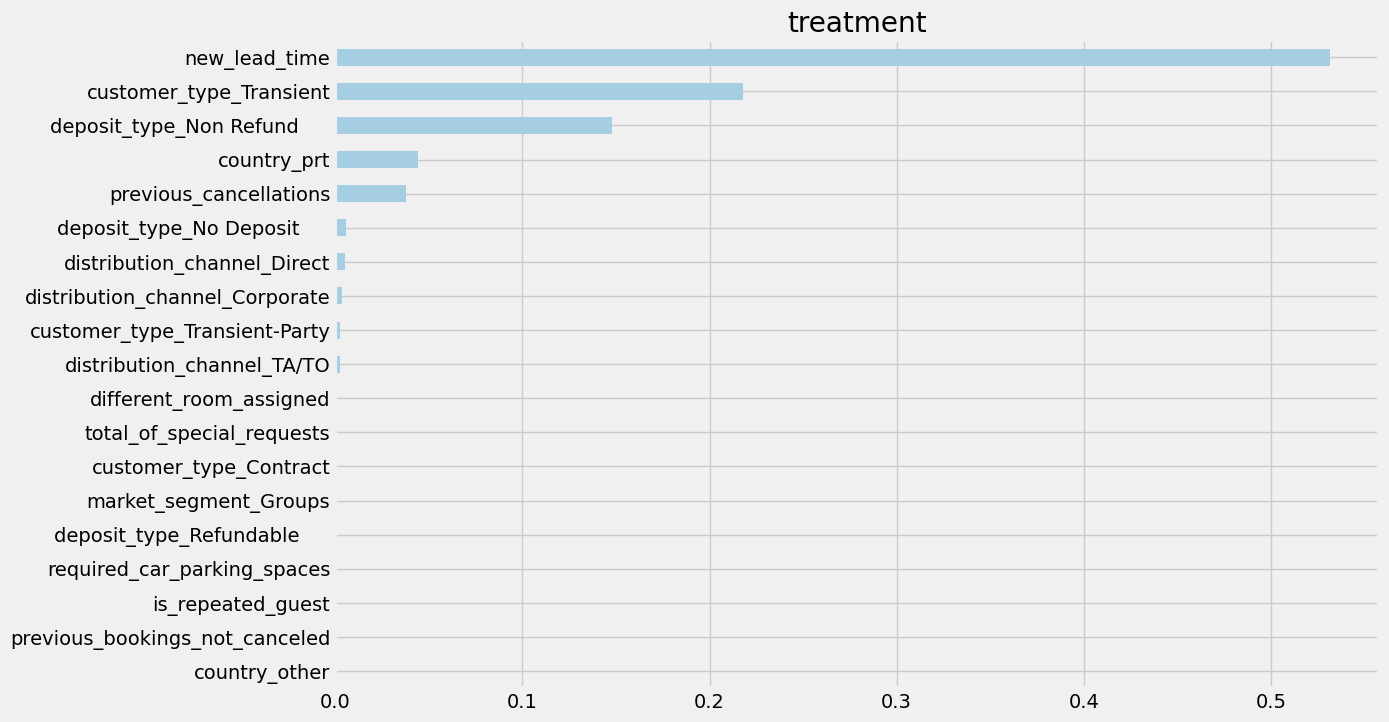

In [ ]:
s_learner.plot_importance(
    X=df_train[features].values,
    tau=slearner_tau,
    normalize=True,
    method="auto",
    features=features
)

In [ ]:
s_learner.get_shap_values(df_train[x_n].values,tau = slearner_tau)

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split

{'treatment': array([[ 0.07055511,  0.00070348,  0.00128116, ...,  0.        ,
         -0.00940325,  0.00642495],
        [-0.00022514, -0.00178827,  0.00130211, ...,  0.        ,
         -0.05202116,  0.00092435],
        [-0.00864749,  0.00126027,  0.00081483, ...,  0.        ,
         -0.01698979,  0.00162864],
        ...,
        [ 0.00637524,  0.00020921,  0.00087034, ...,  0.        ,
          0.05762484, -0.00070029],
        [-0.02376835,  0.00028792,  0.00077306, ...,  0.        ,
          0.02267035, -0.0079921 ],
        [-0.03263327,  0.00021274,  0.00087938, ...,  0.        ,
         -0.06752231, -0.00198767]])}

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split

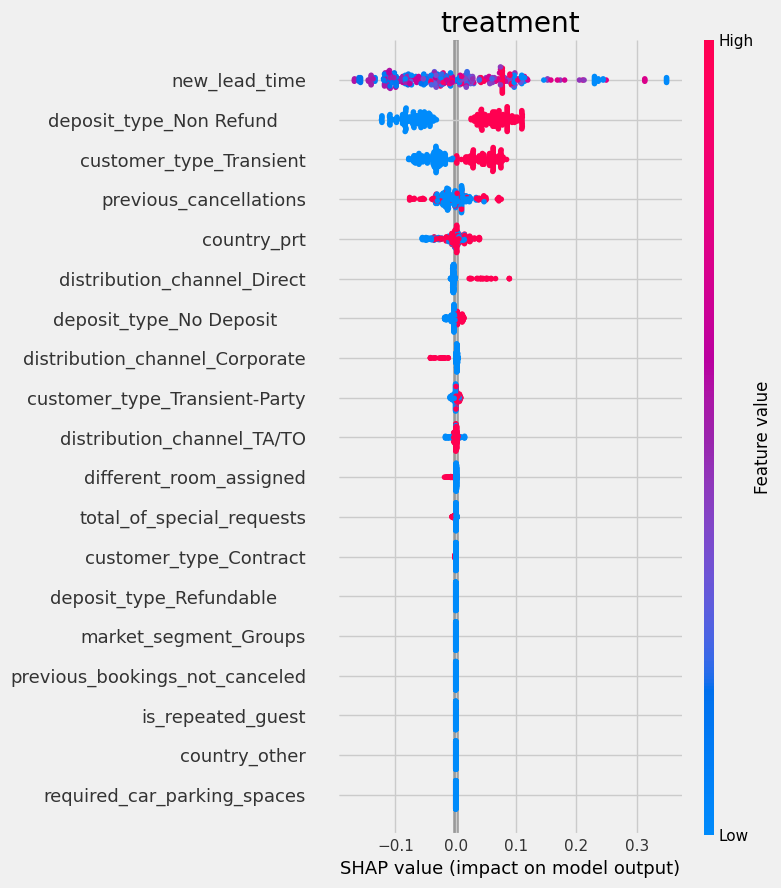

In [ ]:
s_learner.plot_shap_values(
    X=df_train[features].values,
    tau=slearner_tau,
    features=features
)

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split

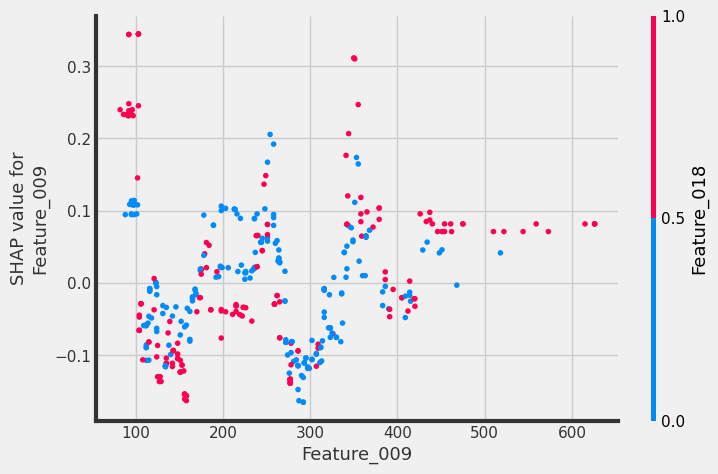

In [ ]:
s_learner.plot_shap_dependence(treatment_group="treatment",feature_idx=9,X=df_train[x_n].values,tau= slearner_tau,interaction_idx="auto")

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split

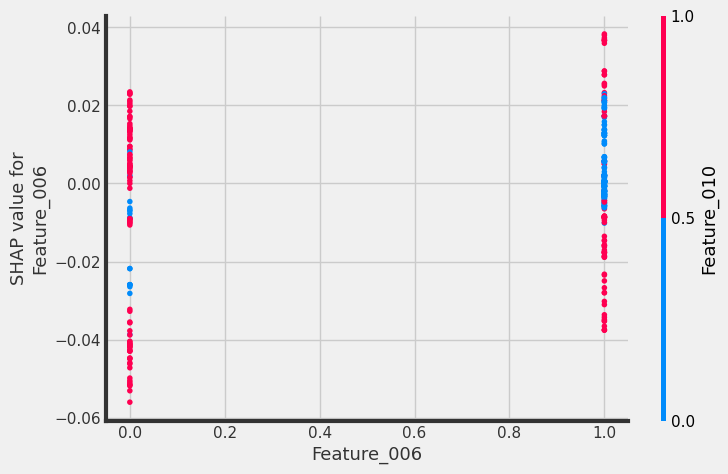

In [ ]:
s_learner.plot_shap_dependence(treatment_group="treatment",feature_idx=6,X=df_train[x_n].values,tau= slearner_tau,interaction_idx="auto")

In [ ]:
from causalml.optimize import get_treatment_costs,get_actual_value


In [ ]:
conver_cost_dict = {'control':0,'treatment':150}
imp_cost_dict = {'control':0,'treatment':0}



In [ ]:
# Map treatment indicators to strings to match the cost dictionaries and control_name
treatment_labels = df_n['treatment_control'].map({0: 'control', 1: 'treatment'})

cc_array, ic_array, conditions = get_treatment_costs(
    treatment=treatment_labels,
    control_name="control",
    cc_dict=conver_cost_dict,
    ic_dict=imp_cost_dict
)

print("Costs arrays and conditions created successfully.")

Costs arrays and conditions created successfully.


In [ ]:
conver_val_array = np.full(500,1500)

In [ ]:
# 1. Define conditions exactly as expected
conditions_list = ['control', 'treatment']

# 2. Map treatment to strings to match library expectations
treatment_labels_n = df_n['treatment_control'].map({0: 'control', 1: 'treatment'}).values.astype(str)

# 3. Create the 2D cost matrices (N x n_conditions)
# For each row, we provide the cost if they were in control (col 0) and if in treatment (col 1)
n_obs = len(df_n)
cc_matrix = np.zeros((n_obs, len(conditions_list)))
ic_matrix = np.zeros((n_obs, len(conditions_list)))

for i, cond in enumerate(conditions_list):
    cc_matrix[:, i] = conver_cost_dict[cond]
    ic_matrix[:, i] = imp_cost_dict[cond]

# 4. Prepare other inputs
observed_outcomes_n = df_n['conversion'].values
conver_val_array_n = np.full(n_obs, 1500)

# 5. Calculate actual value using the matrices
actual_value = get_actual_value(
    treatment=treatment_labels_n,
    observed_outcome=observed_outcomes_n,
    conversion_value=conver_val_array_n,
    conditions=conditions_list,
    conversion_cost=cc_matrix,
    impression_cost=ic_matrix
)



(array([312.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 188.]),
 array([   0.,  150.,  300.,  450.,  600.,  750.,  900., 1050., 1200.,
        1350., 1500.]),
 <BarContainer object of 10 artists>)

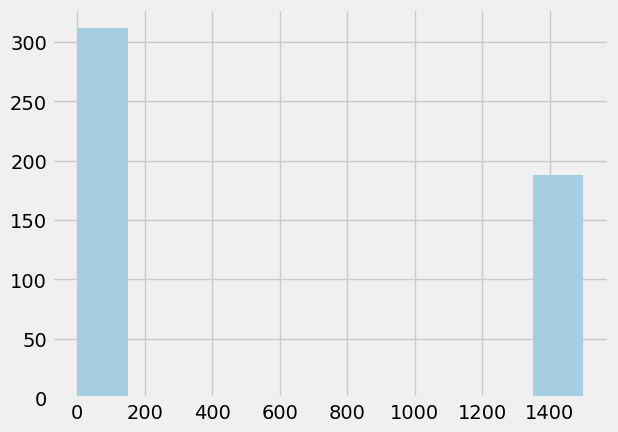

In [ ]:
plt.hist(actual_value)

In [ ]:
train_idx = df_train.index
test_idx = df_test.index

In [ ]:

test_pos = [df_n.index.get_loc(idx) for idx in test_idx]
rand_alloc_value = actual_value[test_pos].mean()



In [ ]:
best_ate = df_train.groupby('treatment_control')['conversion'].mean().idxmax()

In [ ]:
actual_best_ate = df_test["treatment_control"] == best_ate

In [ ]:

best_ate_val = actual_value[test_pos][actual_best_ate.values].mean()



In [ ]:
from lightgbm import LGBMClassifier

tm = BaseTClassifier(control_learner=LGBMClassifier(), treatment_learner=LGBMClassifier(), control_name="control")

treatment_map = {0: 'control', 1: 'treatment'}
treatment_series = df_train['treatment_control'].map(treatment_map).values
features = [f for f in x_n if f not in ['conversion', 'treatment_control']]

tm.fit(df_train[features].values, treatment_series, df_train["conversion"])

print("BaseTClassifier fitted successfully!")

[LightGBM] [Info] Number of positive: 84, number of negative: 166
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000071 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 89
[LightGBM] [Info] Number of data points in the train set: 250, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.336000 -> initscore=-0.681171
[LightGBM] [Info] Start training from score -0.681171
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

In [ ]:
tm_pred = tm.predict(df_test[features].values)

In [ ]:
features

['previous_cancellations',
 'total_of_special_requests',
 'different_room_assigned',
 'required_car_parking_spaces',
 'previous_bookings_not_canceled',
 'is_repeated_guest',
 'country_prt',
 'country_other',
 'new_lead_time',
 'deposit_type_No Deposit     ',
 'deposit_type_Non Refund     ',
 'deposit_type_Refundable     ',
 'market_segment_Groups',
 'distribution_channel_Corporate',
 'distribution_channel_Direct',
 'distribution_channel_TA/TO',
 'customer_type_Contract',
 'customer_type_Transient',
 'customer_type_Transient-Party']

In [ ]:
pred_df = pd.DataFrame(tm_pred, columns=tm._classes)
tm_best = pred_df.idxmax(axis=1)

In [ ]:
# Map the numeric treatment_control to strings to match tm_best predictions
treatment_map = {0: 'control', 1: 'treatment'}
actual_test_labels = df_test["treatment_control"].map(treatment_map)

actucal_tm_best = (actual_test_labels.values == tm_best.values.ravel())

# Calculate the mean value for cases where the predicted best treatment matches the actual treatment
tm_val = actual_value[test_pos][actucal_tm_best].mean()
print(f"T-Learner Value: {tm_val}")

T-Learner Value: 486.0


In [ ]:
tm_val

np.float64(486.0)

In [ ]:
labels = ["random allocation","best treatment","t-learner"]

In [ ]:
val = [rand_alloc_value,best_ate_val,tm_val]

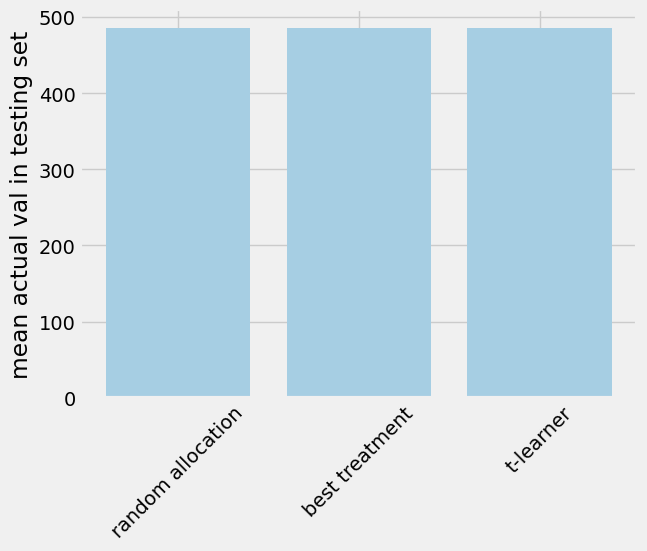

In [ ]:
plt.bar(labels,val)
plt.ylabel("mean actual val in testing set")
plt.xticks(rotation= 45)
plt.show()

In [ ]:
df2.groupby("treatment_control")["accept_offer"]\
    .agg(["sum", "count"]) \
    .assign(acceptance_rate = lambda x: x["sum"] / x["count"])

,sum,count,acceptance_rate
treatment_control,,,
0,0,250,0.00
1,60,250,0.24


In [ ]:
df2.groupby(["treatment_control","accept_offer"])["is_canceled"] \
.agg(["sum","count"]) \
.assign(cancellation_rate = lambda x: x["sum"] / x["count"])

sum  count  cancellation_rate
treatment_control accept_offer                               
0                 0             166    250           0.664000
1                 0             135    190           0.710526
                  1              11     60           0.183333

In [ ]:
average_spend = 1500
disc_90_days_out = 0.1
gross_revenue  = 49*1500*(1-0.1)

In [ ]:
gross_revenue

66150.0

In [ ]:
lost_revenue = 49*1500*0.30##30% will be accepted anyway, even if we don't give them treatment.
lost_revenue

22050.0

In [ ]:
Net_rev = gross_revenue - lost_revenue
Net_rev

44100.0

In [ ]:
net_rev_per_customer = Net_rev/250
net_rev_per_customer

176.4

In [ ]:
# Calculate total number of people in the 'Groups' market segment
groups_count = df[df['market_segment'] == 'Groups'].shape[0]
print(f"Total number of people in market segment 'Groups': {groups_count}")

Total number of people in market segment 'Groups': 19811


In [ ]:
##Total revenue for the people who are in the market segment == "Groups"

In [ ]:
estimated_roi = 19811*net_rev_per_customer
estimated_roi_str = f"${estimated_roi:.2f}"
print(f"Estimated ROI for market segment 'Groups': {estimated_roi_str}")

Estimated ROI for market segment 'Groups': $3494660.40
